# Vgg16 to recognize pneumonia

In [1]:
!python --version

Python 3.12.2


In [ ]:
#!pip install setuptools wheel tensorflow opencv-python matplotlib opencv-python

In [3]:
import tensorflow as tf
print(tf.__version__)
import os

# Limiter le nombre de threads utilisés par TensorFlow
# 12 coeurs sur mon AMD Ryzen 5 5500U
os.environ["OMP_NUM_THREADS"] = "9"
os.environ["TF_NUM_INTRAOP_THREADS"] = "9"
os.environ["TF_NUM_INTEROP_THREADS"] = "9"
tf.config.threading.set_intra_op_parallelism_threads(9)  # Nombre de threads pour les opérations internes
tf.config.threading.set_inter_op_parallelism_threads(9)  # Nombre de threads pour les opérations indépendantes

2.16.1


In [4]:
import numpy as np
from tensorflow.random import set_seed

np.random.seed(123)
set_seed(123) # Setting the seed in programming ensures reproducibility and consistency in results, making it crucial for debugging, fair comparisons, and reliable experiments.

In [5]:
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
import cv2

class ImagePaddingTransformer(TransformerMixin):
    def __init__(self,  padding_val=0):
        self.padding_val = padding_val
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        padded_images = []
        for image in X:
            if len(image.shape) == 2:  # Image en niveaux de gris
                print("gray image found")
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
                
            height, width, channels = image.shape[0], image.shape[1], image.shape[2]
            max_dim = max(height, width)
            pad_vertical = round((max_dim - height) / 2)
            pad_horizontal = round((max_dim - width) / 2)
            padded_image = np.pad(image, ((pad_vertical, pad_vertical), (pad_horizontal, pad_horizontal), (0,0)), mode='constant', constant_values=self.padding_val)
            padded_images.append(padded_image)
        
        return padded_images

In [6]:
import cv2

class ImageResizingTransformer(TransformerMixin):
    def __init__(self, size):
        self.size = size
    
    def fit(self, X, y=None):
        # X = check_array(X, force_all_finite=True, allow_nd=True)
        return self
    
    def transform(self, X):
        # Check input array
        # X = check_array(X, force_all_finite=True, allow_nd=True)
        
        # Create a new array with resized images
        resized_images = []
        for image in X:
            resized_image = cv2.resize(image, (self.size, self.size))
            # reshape as 1D array
            resized_images.append(resized_image)
        
        return np.array(resized_images)

In [7]:
# This function loads all the images
# following the dataset format from the provided path

import cv2
import os
import random

def load_images_from_folder(folder_path, image_files, X, y, label):
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        image = cv2.imread(image_path)
        
        if len(image.shape) == 2:  # Image en niveaux de gris
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        X.append(image)
        y.append(label)

def load_data(data_paths, start_ratio, end_ratio): # data_paths=array
    
    # Get the list of all the images
    X = []
    y = []
    
    
    transformer = ImageResizingTransformer(size=224)
    
    for data_path in data_paths:

        # Get Normal Images
        n_paths = os.listdir(os.path.join(data_path, 'NORMAL'))
        # Sort by name
        n_paths.sort()
        # remove the hidden files
        n_paths = [f for f in n_paths if f.endswith('.jpeg')]
        
        start_index = int(len(n_paths) * start_ratio)
        end_index = int(len(n_paths) * end_ratio)
        
        n_paths_sampled = n_paths[start_index:end_index]
            

        # Get Pneumonia Images
        p_paths = os.listdir(os.path.join(data_path, 'PNEUMONIA'))
        
        
        # Sort by name
        p_paths.sort()
        # remove the hidden files
        p_paths = [f for f in p_paths if f.endswith('.jpeg')]

        start_index = int(len(p_paths) * start_ratio)
        end_index = int(len(p_paths) * end_ratio)
        
        p_paths_sampled = p_paths[start_index:end_index]

        # Iterate through the NORMAL folder
        load_images_from_folder(os.path.join(data_path, 'NORMAL'), n_paths_sampled, X, y, label=0)
    
        # Iterate through the PNEUMONIA folder
        load_images_from_folder(os.path.join(data_path, 'PNEUMONIA'), p_paths_sampled, X, y, label=1)

    return X, y

In [8]:
TRAIN_DATA_PATH = 'datasets/chest_Xray/train'
VAL_DATA_PATH = 'datasets/chest_Xray/val'
TEST_DATA_PATH = 'datasets/chest_Xray/test'
data_paths = [TRAIN_DATA_PATH, VAL_DATA_PATH, TEST_DATA_PATH]

In [9]:
import sys
from collections.abc import MutableSequence

def get_size(obj): # Get memory size of array
    size = sys.getsizeof(obj)
    if isinstance(obj, MutableSequence):
        size += sum(get_size(item) for item in obj)

    size_in_mb = size / (1024 * 1024)
    
    return size

In [10]:
from sklearn.pipeline import Pipeline

vgg_pre = Pipeline([
    ('padding', ImagePaddingTransformer(padding_val=0)),
    ('resizing', ImageResizingTransformer(size=224)),
])

def prepare_for_vgg(X, y):
    X = vgg_pre.fit_transform(X)
    X = np.array(X).reshape(-1, 224, 224, 3)
    X = X / 255.0
    y = np.array(y)
    return X, y

In [11]:

# As the images are loud we have to preprocess while loading to avoid memory error 

def load_and_preprocess_data(num_iterations):
    
    quotient = 100 / num_iterations
    percentage_ratio = quotient / 100
    
    X_all = []
    y_all = []

    
    for i in range(num_iterations):
        
        start_ratio = percentage_ratio * i
        end_ratio = (percentage_ratio * i) + percentage_ratio

        X_batch, y_batch = load_data(data_paths, start_ratio, end_ratio)
        x_vgg_batch, y_vgg_batch = prepare_for_vgg(X_batch, y_batch)
        
        if i == 0:
            X_all = x_vgg_batch
            y_all = y_vgg_batch
        else:
            X_all = np.concatenate((X_all, x_vgg_batch))
            y_all = np.concatenate((y_all, y_vgg_batch))
        
        del X_batch
        del y_batch
        del x_vgg_batch
        del y_vgg_batch
    
    return X_all, y_all

In [12]:
x_all, y_all = load_and_preprocess_data(50) # We will load 20% by 20% to avoid memory error

In [13]:
print(f"Taille en mémoire : {get_size(x_all):.2f} Mo")
print(len(x_all))

Taille en mémoire : 7050731680.00 Mo
5855


## Data augmentation ##

In [14]:
import numpy as np
import albumentations as A

# Creating a pipeline to augment dataset with little modifications on images

transform = A.Compose([
    A.Rotate(limit=15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.HorizontalFlip(p=0.5)
])

x_train_uint8 = np.array(x_all).astype(np.uint8)


INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.11 (you have 1.4.10). Upgrade using: pip install --upgrade albumentations
C:\Users\jajja\AppData\Roaming\Python\Python312\site-packages\pydantic\main.py:192: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  self.__pydantic_validator__.validate_python(data, self_instance=self)


In [15]:


augmented_images = []
augmented_labels = []

dataset_half_length = len(x_all) // 5 # Avoid memory error

for image, label in zip(x_train_uint8[:dataset_half_length], y_all[:dataset_half_length]):
    augmented = transform(image=image)['image']
    augmented_images.append(augmented)
    augmented_labels.append(label)

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Augmented images length: ", len(augmented_images))

x_all = np.concatenate((x_all, augmented_images))
x_all = np.array(x_all).astype(np.float64)

y_all = np.concatenate((y_all, augmented_labels))

print("New dataset length: ", len(x_all))

Augmented images length:  1171
New dataset length:  7026


In [16]:
del augmented_images
del augmented_labels

In [17]:
from sklearn.model_selection import train_test_split

# Split the data to a train/val/test ratio of 70%/15%/15% in a stratified fashion
# Split train in 70%/30%
x_train, x_val, y_train, y_val = train_test_split(x_all, y_all, stratify=y_all, shuffle=True, random_state=123, test_size=0.3)

# Then split val in 50%/50% with the 30% -> resulting in 70%/15%/15%
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, stratify=y_val, shuffle=True, random_state=123, test_size=0.5)

In [18]:
# Print the number of images in each dataset
print('Number of Training Images:', len(x_train))
print('Number of Training Labels:', len(y_train))

if len(x_train) != len(y_train):
    raise ValueError("Images and labels lengths not corresponding for training dataset.")

print('Number of Validation Images:', len(x_val))
print('Number of Validation Labels:', len(y_val))

if len(x_val) != len(y_val):
    raise ValueError("Images and labels lengths not corresponding for validation dataset.")

print('Number of Testing Images:', len(x_test))
print('Number of Testing Labels:', len(y_test))

if len(x_test) != len(y_test):
    raise ValueError("Images and labels lengths not corresponding for test dataset.")

Number of Training Images: 4918
Number of Training Labels: 4918
Number of Validation Images: 1054
Number of Validation Labels: 1054
Number of Testing Images: 1054
Number of Testing Labels: 1054


## VGG16


In [19]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Will be used in next model

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras import models, layers

# Add layers on top of VGG16 base model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # "fully connected", fait des prédictions basées sur les caractéristiques extraites. Vous pouvez utiliser plusieurs couches fully connected avec des unités ReLU ou d'autres fonctions d'activation.
    layers.Dropout(0.5), #  aide à prévenir le sur-apprentissage en désactivant aléatoirement des neurones pendant l'entraînement.
    layers.Dense(1, activation='sigmoid') # Classification dense, affine les résultats, "sigmoid" pour les classifications binaires
])

# Don't train VGG16 layers, only added layers will be trained
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer='adam', # Adam is the best
    loss='binary_crossentropy',  # Fonction de perte pour classification binaire. Cette fonction de perte est cruciale car elle mesure à quel point les prédictions du modèle correspondent aux vraies étiquettes (ou cibles) lors de l'entraînement du modèle.
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.FalsePositives(name='false_positives')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ ?                           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Train the model

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

# Vérifier les types et les formes des données

assert isinstance(x_train, np.ndarray), "x_train doit être un tableau NumPy"
assert isinstance(y_train, np.ndarray), "y_train doit être un tableau NumPy"
assert x_train.shape[0] == y_train.shape[0], "x_train et y_train doivent avoir le même nombre d'exemples"

# Assurez-vous que les étiquettes sont au bon format (ex. : (1000,) ou (1000, 1))
if y_train.ndim == 2 and y_train.shape[1] == 1:
    y_train = y_train.squeeze()

if y_val.ndim == 2 and y_val.shape[1] == 1:
    y_val = y_val.squeeze()
 

batch_size = 32 # Essayer différentes tailles de batch pour obtenir des modèles plus précis: 128, 256, 512 ce qui demandera plus de mémoire et un gpu

model_path = "./vgg16.h5"

#from tensorflow.keras.callbacks import TensorBoard
#tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)
#%load_ext tensorboard
#%reload_ext tensorboard
#%tensorboard --logdir ./logs

history_file_name = 'history.json' 
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

if not os.path.isfile(model_path):
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=20,
        validation_data=(x_val, y_val),
        callbacks=[early_stopping]
        #callbacks=[tensorboard_callback]
    )
    
    model.save(model_path)
   
    import json
    with open(history_file_name, 'w') as f:
        json.dump(history.history, f)
else:
    from tensorflow.keras.models import load_model
    model = load_model(model_path)

    with open(history_file_name, 'r') as f:
        history = json.load(f)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 713s 5s/step - accuracy: 0.8291 - auc: 0.8508 - false_positives: 224.1355 - loss: 0.5365 - precision: 0.8660 - recall: 0.9031 - val_accuracy: 0.9127 - val_auc: 0.9636 - val_false_positives: 82.0000 - val_loss: 0.2165 - val_precision: 0.9025 - val_recall: 0.9870
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 713s 5s/step - accuracy: 0.9064 - auc: 0.9541 - false_positives: 166.5806 - loss: 0.2341 - precision: 0.9137 - recall: 0.9616 - val_accuracy: 0.9222 - val_auc: 0.9699 - val_false_positives: 63.0000 - val_loss: 0.1851 - val_precision: 0.9225 - val_recall: 0.9753
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 715s 5s/step - accuracy: 0.9200 - auc: 0.9646 - false_positives: 161.7871 - loss: 0.2024 - precision: 0.9199 - recall: 0.9746 - val_accuracy: 0.9213 - val_auc: 0.9697 - val_false_positives: 63.0000 - val_loss: 0.1832 - val_precision: 0.9224 - val_recall: 0.9740
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 713s 5s/step - accuracy: 0.9214 - auc: 0.9669 - false_

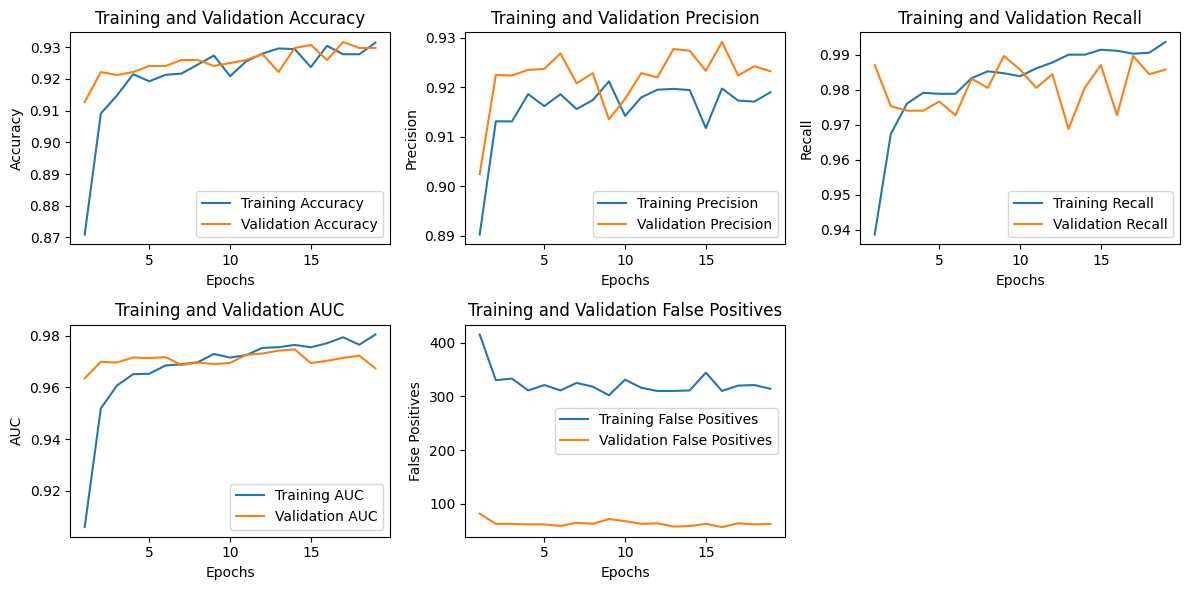

In [22]:
import matplotlib.pyplot as plt

def show_results ():
        
    
    # Récupération des métriques historiques
    train_accuracy = history.history['accuracy']
    train_precision = history.history['precision']
    train_recall = history.history['recall']
    train_auc = history.history['auc']
    train_false_positives = history.history['false_positives']
    
    # Validation accuracy
    val_accuracy = history.history['val_accuracy']
    val_precision = history.history['val_precision']
    val_recall = history.history['val_recall']
    val_auc = history.history['val_auc']
    val_false_positives = history.history['val_false_positives']
    
    # Affichage des courbes
    epochs = range(1, len(train_accuracy) + 1)
    
    plt.figure(figsize=(12, 6))
    
    # Accuracy
    plt.subplot(2, 3, 1)
    plt.plot(epochs, train_accuracy, label='Training Accuracy')
    plt.plot(epochs, val_accuracy, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Precision
    plt.subplot(2, 3, 2)
    plt.plot(epochs, train_precision, label='Training Precision')
    plt.plot(epochs, val_precision, label='Validation Precision')
    plt.title('Training and Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    
    # Recall
    plt.subplot(2, 3, 3)
    plt.plot(epochs, train_recall, label='Training Recall')
    plt.plot(epochs, val_recall, label='Validation Recall')
    plt.title('Training and Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()
    
    # AUC
    plt.subplot(2, 3, 4)
    plt.plot(epochs, train_auc, label='Training AUC')
    plt.plot(epochs, val_auc, label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    
    # False Positives
    plt.subplot(2, 3, 5)
    plt.plot(epochs, train_false_positives, label='Training False Positives')
    plt.plot(epochs, val_false_positives, label='Validation False Positives')
    plt.title('Training and Validation False Positives')
    plt.xlabel('Epochs')
    plt.ylabel('False Positives')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


show_results()

In [23]:
loss, accuracy, *is_anything_else_being_returned = model.evaluate(x_test, y_test)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

33/33 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.9470 - auc: 0.9746 - false_positives: 28.7059 - loss: 0.1580 - precision: 0.9387 - recall: 0.9910
Loss: 0.16542746126651764
Accuracy: 0.9411764740943909


In [24]:
y_pred_prob = model.predict(x_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step


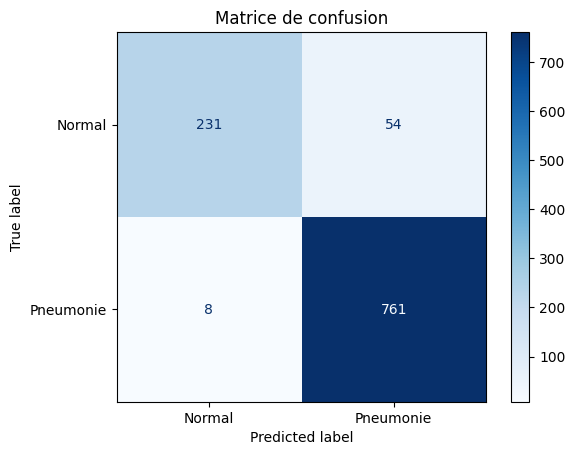

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert probabilities to binary predictions (0 or 1)
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
labels = ['Normal', 'Pneumonie']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)

plt.title('Matrice de confusion')
plt.show()